# Camera calibration: pixels to metres

**Goal:** Map image coordinates to road distances and save `calibration.yaml` for the app.

**Interview summary:** I trace road markings to estimate the horizon and camera height, use UniDepth v2 for focal length, then build a road-plane homography and account for the road's curve.

| Quantity | Source |
|---|---|
| Road width `W` | Assumed 5 lanes x 3.63 m = 18.15 m |
| Horizon `y0` | Zero crossing of the fitted gap between road edges |
| Camera height `h` | Road width divided by the fitted slope |
| Focal length `f` | Median UniDepth v2 intrinsics across six frames |

The geometry assumes a level horizon. Focal length affects distance along the road and speed; a consistent estimate alone does not prove the scale is correct.

## 0. Setup and data

Use a Colab GPU for UniDepth. Load the clips from a local archive or Kaggle.


In [1]:
%pip install -q kagglehub
%pip install -q git+https://github.com/lpiccinelli-eth/UniDepth.git


  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 54.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 750.0/750.0 kB 29.6 MB/s eta 0:00:00


In [2]:
import pathlib
import shutil

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Copy the Kaggle cache into a folder visible in Colab's file browser.
LOCAL = pathlib.Path('../archive')
if LOCAL.exists():
    DATA = LOCAL
else:
    import kagglehub

    content = pathlib.Path('/content')
    DATA = (content if content.exists() else pathlib.Path.cwd()) / 'traffic-data'
    if not DATA.exists():
        cache = kagglehub.dataset_download('aryashah2k/highway-traffic-videos-dataset')
        shutil.copytree(next(pathlib.Path(cache).rglob('info.txt')).parent, DATA)
VIDEO = DATA / 'video'

COLUMNS = ['filename', 'date', 'timestamp', 'direction', 'day_night', 'weather',
           'start_frame', 'n_frames', 'label', 'notes']
info = pd.read_csv(DATA / 'info.txt', sep='\t', comment='#', names=COLUMNS,
                   encoding_errors='replace').set_index('filename')
DAY1, DAY2 = sorted(info['date'].unique())
FIRST_FRAME = 2          # the database README: frame 1 carries another video signal

print(DATA.resolve(), '\u00b7', len(info), 'clips \u00b7', DAY1, 'and', DAY2)

Using Colab cache for faster access to the 'highway-traffic-videos-dataset' dataset.
/content/traffic-data · 254 clips · 20040805 and 20040806


## 1. Build road backgrounds

Take a per-pixel median of light-traffic frames for each day to reduce visible vehicles. Compare the backgrounds to estimate the camera shift between days.

Use day 2 for calibration. The roadway crop starts at `x >= 112` to retain the yellow edge on both days.


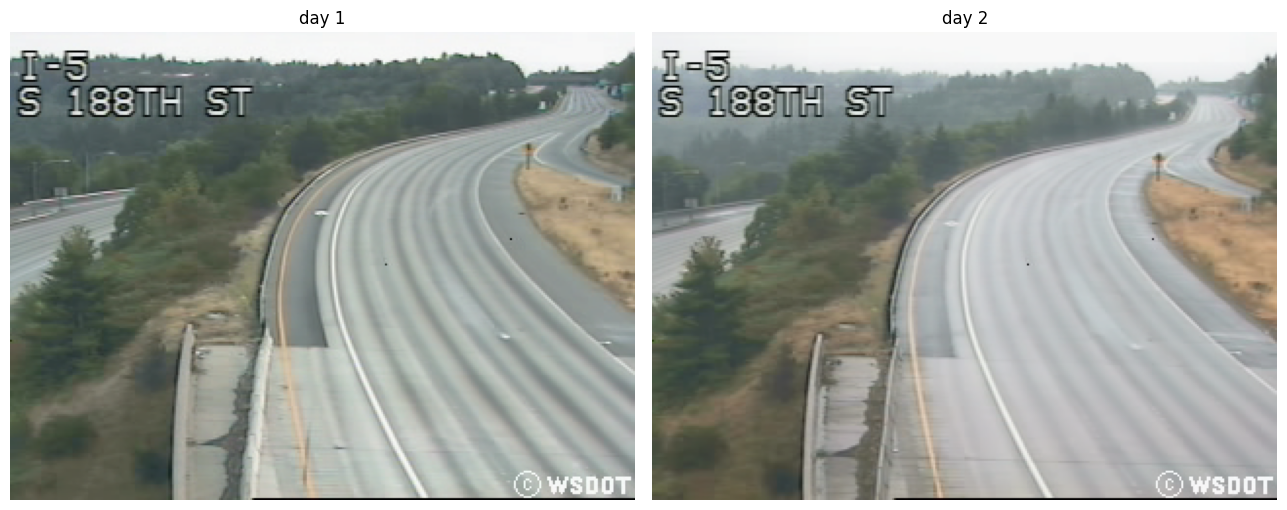

day 1 -> day 2   dx -6.02 px   dy +5.35 px  (confidence 0.702)


In [3]:
def median_background(names, per_clip=4):
    """Per-pixel median over a few frames from each clip, as one RGB image."""
    samples = []
    for name in names:
        step = max(1, (info.at[name, 'n_frames'] - FIRST_FRAME) // per_clip)
        capture, number, taken = cv2.VideoCapture(str(VIDEO / f'{name}.avi')), 0, 0
        while taken < per_clip:
            ok, frame = capture.read()
            if not ok:
                break
            number += 1
            if number >= FIRST_FRAME and (number - FIRST_FRAME) % step == 0:
                samples.append(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
                taken += 1
        capture.release()
    # Keep samples as uint8 to avoid a larger float32 copy.
    return np.median(np.asarray(samples), axis=0).round().astype(np.uint8)


light = info[info['label'] == 'light']
BG1 = median_background(light.index[light['date'] == DAY1])
BG2 = median_background(light.index[light['date'] == DAY2])
BG = BG2                                          # day 2 has the larger sample

grey = [cv2.cvtColor(image, cv2.COLOR_RGB2GRAY).astype(np.float32) for image in (BG1, BG2)]
window = cv2.createHanningWindow(grey[0].shape[::-1], cv2.CV_32F)
(dx, dy), confidence = cv2.phaseCorrelate(grey[0] * window, grey[1] * window)
DAY_SHIFT = {'dx': round(float(dx), 2), 'dy': round(float(dy), 2)}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, image, title in zip(axes, (BG1, BG2), ('day 1', 'day 2')):
    ax.imshow(image); ax.set_title(title); ax.axis('off')
plt.tight_layout(); plt.show()

print(f'day 1 -> day 2   dx {dx:+.2f} px   dy {dy:+.2f} px  (confidence {confidence:.3f})')

## 2. Trace road markings

Subtract a blurred image to highlight the paint, then trace the yellow left edge, the HOV divider, and the white right edge from manual seed points.

Inspect the plotted traces before using the geometry. Move a seed if its trace leaves the marking. At 320 x 240, the dashed lines are too small to use their spacing for scale.


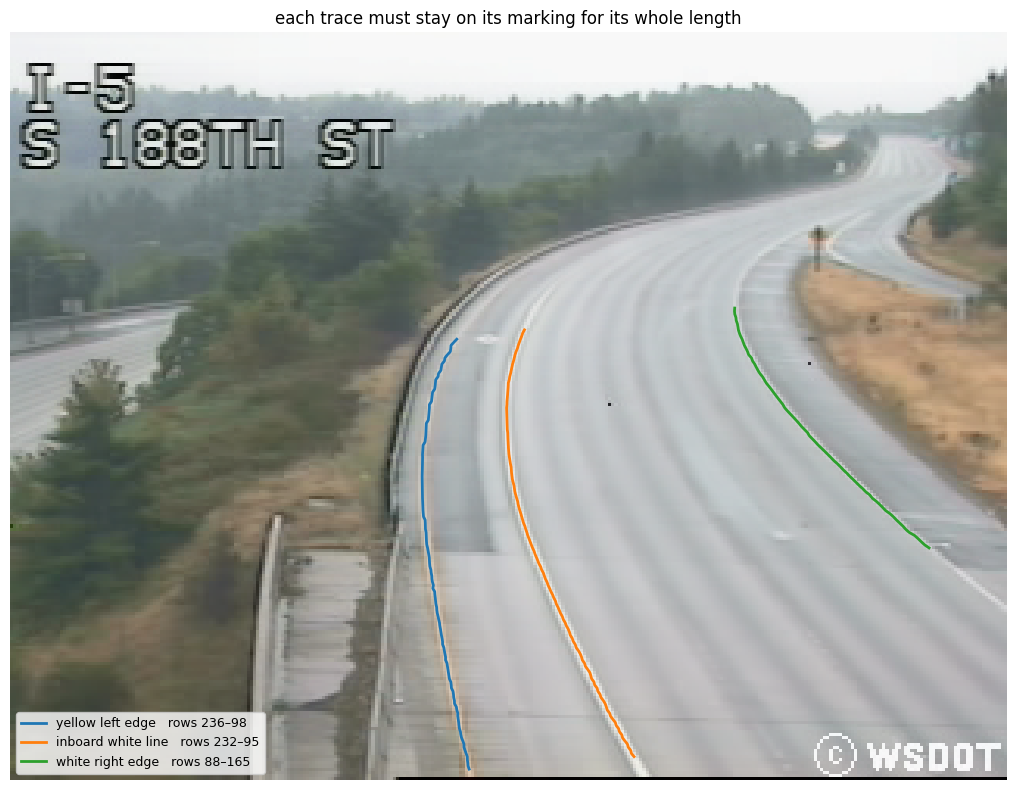

In [7]:
gray = cv2.cvtColor(BG, cv2.COLOR_RGB2GRAY).astype(np.float32)
lift = gray - cv2.GaussianBlur(gray, (0, 0), 9)     # paint, with the lighting removed


def trace(seed_x, seed_y, end_y, search=4, min_brightness=3.0):
    """Follow one marking row by row. Returns ``(N, 2)`` of ``(row, column)``."""
    step = 1 if end_y > seed_y else -1
    x, found = float(seed_x), []
    for row in range(seed_y, end_y + step, step):
        lo, hi = max(0, int(x - search)), min(lift.shape[1], int(x + search) + 1)
        chunk = lift[row, lo:hi]
        if chunk.size == 0:
            break
        peak = lo + int(chunk.argmax())
        if chunk.max() < min_brightness:
            continue                                # lost it; keep the last position
        weights = lift[row, max(0, peak - 1):peak + 2].clip(0)
        columns = np.arange(max(0, peak - 1), peak + 2)[:len(weights)]
        if weights.sum() > 0:
            x = float((weights * columns).sum() / weights.sum())
        found.append((row, x))
    found = np.array(found, float).reshape(-1, 2)
    assert len(found) >= 5, f'trace from ({seed_x}, {seed_y}) lost the paint -- move the seed'
    return found


# Trace arguments: seed column, seed row, final row.
LEFT = trace(147, 236, 98)        # yellow left edge -- the lateral origin
HOV = trace(200, 232, 95)         # solid white line inboard of it

# Trace both directions from the right-edge seed to extend the fitting baseline.
RIGHT = np.concatenate([trace(235, 100, 88)[::-1], trace(235, 100, 165)[1:]])

fig, ax = plt.subplots(figsize=(11, 8))
ax.imshow(BG)
for path, name in ((LEFT, 'yellow left edge'), (HOV, 'inboard white line'),
                   (RIGHT, 'white right edge')):
    ax.plot(path[:, 1], path[:, 0], linewidth=2,
            label=f'{name}   rows {path[0, 0]:.0f}\u2013{path[-1, 0]:.0f}')
ax.legend(loc='lower left', fontsize=9)
ax.set_title('each trace must stay on its marking for its whole length')
ax.axis('off'); plt.tight_layout(); plt.show()


## 3. Estimate focal length

Run UniDepth v2 on one real frame per traffic class per day: six frames total. Use the median predicted intrinsics and report the focal-length variation.

Keep the day-2 light frame's depth map for a consistency check in section 4. The road-edge fit supplies the horizon and camera height.


/usr/local/lib/python3.13/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/usr/local/lib/python3.13/dist-packages/unidepth/utils/chamfer_distance.py:9: UserWarning: !! To run evaluation you need KNN. Please compile KNN: `cd unidepth/ops/knn with && bash compile.sh`.
  warnings.warn(


Cannot import NystromAttention, you can not run original UniDepth. UniDepthV2 is available.


config.json:   0%|          | 0.00/3.85k [00:00<?, ?B/s]

Not loading pretrained weights for backbone
EdgeGuidedLocalSSI reverts to a non cuda-optimized operation, you will experince large slowdown, please install it:  `cd ./unidepth/ops/extract_patches && bash compile.sh`


model.safetensors: reconstructing file:   0%|          |  0.00B / 1.42GB            

model.safetensors: downloading bytes:           |  0.00B            

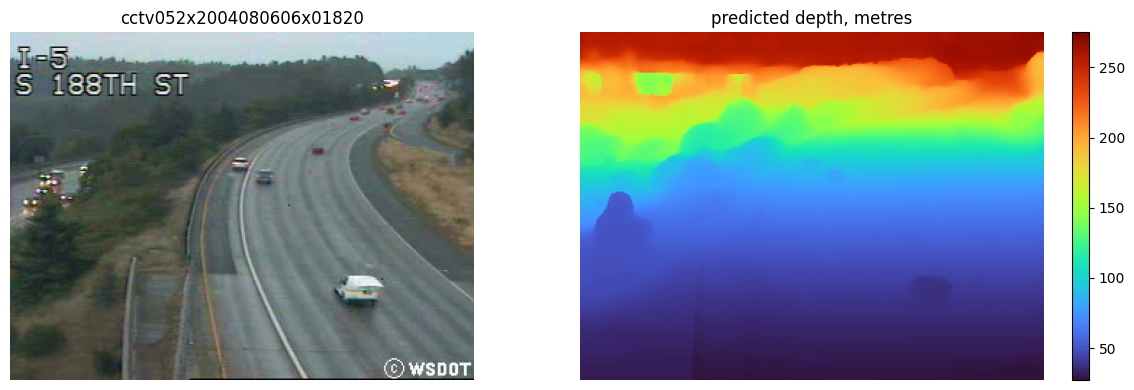

  cctv052x2004080516x01640  20040805  light   f =  773.6 px
  cctv052x2004080516x01638  20040805  medium  f =  782.0 px
  cctv052x2004080516x01646  20040805  heavy   f =  796.6 px
  cctv052x2004080606x01820  20040806  light   f =  800.5 px
  cctv052x2004080613x00018  20040806  medium  f =  790.4 px
  cctv052x2004080614x00026  20040806  heavy   f =  798.9 px
f = 793.5 px (median)  ->  22.8 deg field of view; frame-to-frame spread 3.4%


In [8]:
import torch
from unidepth.models import UniDepthV2

REPO = 'lpiccinelli/unidepth-v2-vitl14'      # not -v2old-, which fails on a missing key
RESOLUTION_LEVEL = 9                          # set explicitly so runs repeat
FRAME_NUMBER = FIRST_FRAME + 20

SCENE = info.index[(info['label'] == 'light') & (info['date'] == DAY2)][0]
CHECK_SCENES = [info.index[(info['label'] == label) & (info['date'] == day)][0]
                for day in (DAY1, DAY2) for label in ('light', 'medium', 'heavy')]


def read_frame(name, number=FRAME_NUMBER):
    capture = cv2.VideoCapture(str(VIDEO / f'{name}.avi'))
    for _ in range(number):
        ok, frame = capture.read()
    capture.release()
    assert ok, f'could not read frame {number} of {name}'
    return cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)


device = 'cuda' if torch.cuda.is_available() else 'cpu'
if device == 'cpu':
    print('WARNING: no GPU -- Runtime > Change runtime type > T4 GPU. CPU works, slowly.')
model = UniDepthV2.from_pretrained(REPO).to(device).eval()
model.resolution_level = RESOLUTION_LEVEL

K_BY_SCENE = {}
for name in CHECK_SCENES:
    image = read_frame(name)
    with torch.no_grad():
        prediction = model.infer(torch.from_numpy(image).permute(2, 0, 1).to(device))
    K_BY_SCENE[name] = prediction['intrinsics'][0].cpu().numpy().astype(float)
    if name == SCENE:
        FRAME, DEPTH = image, prediction['depth'][0, 0].cpu().numpy().astype(float)
del model
if device == 'cuda':
    torch.cuda.empty_cache()

INTRINSICS = np.median(np.stack(list(K_BY_SCENE.values())), axis=0)
fx, fy = INTRINSICS[0, 0], INTRINSICS[1, 1]
PRINCIPAL_X, PRINCIPAL_Y = INTRINSICS[0, 2], INTRINSICS[1, 2]
FIELD_OF_VIEW = float(np.degrees(2 * np.arctan(FRAME.shape[1] / (2 * fx))))
FRAME_FOCALS = np.array([K[0, 0] for K in K_BY_SCENE.values()])
FRAME_SPREAD = float(np.ptp(FRAME_FOCALS) / np.median(FRAME_FOCALS))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(FRAME); axes[0].set_title(SCENE); axes[0].axis('off')
shown = axes[1].imshow(DEPTH, cmap='turbo')
axes[1].set_title('predicted depth, metres'); axes[1].axis('off')
plt.colorbar(shown, ax=axes[1], fraction=.046); plt.tight_layout(); plt.show()

for name, K in K_BY_SCENE.items():
    print(f'  {name}  {info.at[name, "date"]}  {info.at[name, "label"]:<6}  f = {K[0, 0]:6.1f} px')
print(f'f = {fx:.1f} px (median)  ->  {FIELD_OF_VIEW:.1f} deg field of view; '
      f'frame-to-frame spread {FRAME_SPREAD:.1%}')
if not 8 <= FIELD_OF_VIEW <= 65:
    print(f'\nWARNING: {FIELD_OF_VIEW:.0f} deg is outside what fixed traffic cameras use.')
if FRAME_SPREAD > 0.10:
    print(f'\nWARNING: f moves {FRAME_SPREAD:.0%} between frames of a camera that did not zoom.')


## 4. Fit the road plane and check scale

With a level horizon, the pixel gap between road edges follows:

```text
pixel_gap = (W / h) * (row - y0)
horizon y0 = -intercept / slope
camera height h = W / slope
```

Use `1/Z = a*u + b*v + c` for the plane, with `a = 0` to assume no horizon tilt. One vanishing point cannot determine that tilt.

Check the paint-fit residual, plausible camera height, and the HOV lane's width and horizon. Compare the focal length implied by UniDepth's depth map with its intrinsics estimate; both come from the same model, so this is a consistency check.


In [9]:
LANE_COUNT, LANE_WIDTH_M = 5, 3.63
ROAD_WIDTH_M = LANE_COUNT * LANE_WIDTH_M      # the one external number, as in site.yaml


def separation(left, right):
    """Pixel gap between two markings at every row both of them cover."""
    order = np.argsort(right[:, 0])
    usable = (left[:, 0] >= right[:, 0].min()) & (left[:, 0] <= right[:, 0].max())
    rows = left[usable, 0]
    return rows, np.interp(rows, right[order, 0], right[order, 1]) - left[usable, 1]


# Extend the left trace for the gap fit; keep LEFT for the exported road boundary.
paint_rows, paint_gap = separation(trace(147, 236, 88), RIGHT)
PAINT_SLOPE, offset = np.polyfit(paint_rows, paint_gap, 1)
PAINT_RMS = float((paint_gap - np.polyval([PAINT_SLOPE, offset], paint_rows)).std())

HORIZON = float(-offset / PAINT_SLOPE)
CAMERA_HEIGHT_M = float(ROAD_WIDTH_M / PAINT_SLOPE)

a, b = 0.0, float(1 / (fx * CAMERA_HEIGHT_M))
c = float(-b * HORIZON)
INVERSE_K = np.linalg.inv(INTRINSICS)


def on_plane(image_columns, image_rows):
    """Put image points on the road plane. Returns ``(N, 3)`` in camera metres."""
    image_columns = np.asarray(image_columns, float)
    image_rows = np.asarray(image_rows, float)
    homogeneous = np.column_stack([image_columns, image_rows, np.ones(len(image_rows))])
    depth = 1 / (a * image_columns + b * image_rows + c)
    return (homogeneous @ INVERSE_K.T) * depth[:, None]


# Compare the depth-implied focal length with UniDepth's intrinsics estimate.
# Use this as a consistency check; keep the intrinsics estimate for calibration.
def between(first, second):
    """Polygon of the road lying between two traces, over the rows both cover."""
    rows = np.arange(max(first[:, 0].min(), second[:, 0].min()),
                     min(first[:, 0].max(), second[:, 0].max()) + 1)

    def columns_at(path):
        order = np.argsort(path[:, 0])
        return np.interp(rows, path[order, 0], path[order, 1])

    return np.round(np.concatenate([
        np.column_stack([columns_at(first), rows]),
        np.column_stack([columns_at(second), rows])[::-1]])).astype(np.int32)


roadway = np.zeros(DEPTH.shape, np.uint8)
rows_grid, columns_grid = np.mgrid[0:DEPTH.shape[0], 0:DEPTH.shape[1]]
cv2.fillPoly(roadway, [between(LEFT, RIGHT), between(LEFT, HOV)], 1)
roadway = roadway.astype(bool) & np.isfinite(DEPTH) & (DEPTH > 0)

implied = DEPTH[roadway] * (rows_grid[roadway] - HORIZON) / CAMERA_HEIGHT_M
FOCAL_ESTIMATES = {'unidepth_intrinsics': float(fx), 'unidepth_depth': float(np.median(implied))}
FOCAL_PX = float(fx)
SPREAD = float(abs(FOCAL_ESTIMATES['unidepth_depth'] - FOCAL_PX) / FOCAL_PX)

print(f'  y0 = {HORIZON:7.2f}      from the paint, rms {PAINT_RMS:.2f} px over rows '
      f'{paint_rows.min():.0f}-{paint_rows.max():.0f}')
print(f'  W  = {ROAD_WIDTH_M:7.2f} m    {LANE_COUNT} x {LANE_WIDTH_M} m -- external')
print(f'  h  = {CAMERA_HEIGHT_M:7.2f} m    = W / {PAINT_SLOPE:.4f} px per row')
print(f'  f  = {FOCAL_PX:7.1f} px   UniDepth intrinsics; its depth implies '
      f"{FOCAL_ESTIMATES['unidepth_depth']:.0f}, spread {SPREAD:.1%}")

# Check the one-lane HOV width and horizon without changing the calibration.
hov_rows, hov_gap = separation(LEFT, HOV)
HOV_SLOPE, hov_offset = np.polyfit(hov_rows, hov_gap, 1)
HOV_HORIZON = float(-hov_offset / HOV_SLOPE)
HOV_WIDTH_M = float(CAMERA_HEIGHT_M * HOV_SLOPE)
print(f'HOV lane = {HOV_WIDTH_M:5.2f} m    expect ~{LANE_WIDTH_M} m; its horizon '
      f'{HOV_HORIZON:.1f} against the paint {HORIZON:.1f}')

for holds, complaint in (
        (PAINT_RMS <= 0.6, f'the paint fit leaves {PAINT_RMS:.2f} px -- inspect the traces'),
        (3 <= CAMERA_HEIGHT_M <= 30, f'{CAMERA_HEIGHT_M:.1f} m is implausible for a mast'),
        (HORIZON < LEFT[:, 0].min(), 'the horizon is below the top of the traced road'),
        (abs(HOV_WIDTH_M / LANE_WIDTH_M - 1) <= 0.10,
         f'the HOV lane reads {HOV_WIDTH_M:.2f} m -- the lane count or W is wrong'),
        (SPREAD <= 0.15, f'UniDepth depth and intrinsics disagree on f by {SPREAD:.0%}: '
                         'speed is unverified until checked against free flow')):
    if not holds:
        print(f'\nWARNING: {complaint}')


  y0 =    8.90      from the paint, rms 0.29 px over rows 88-165
  W  =   18.15 m    5 x 3.63 m -- external
  h  =   17.62 m    = W / 1.0299 px per row
  f  =   793.5 px   UniDepth intrinsics; its depth implies 412, spread 48.0%
HOV lane =  4.28 m    expect ~3.63 m; its horizon 20.1 against the paint 8.9




## 5. Map the road and account for curvature

Build a homography with coordinates in metres across and along the road. Fit a quadratic to the yellow left edge so the app can measure lateral position relative to the curved boundary.

Save the visible distance range along the road plane. The reported pitch describes the camera, not the road gradient.


camera pitch 7.53 deg   (bank is 0 by construction, not by measurement)
left edge sweeps 3.81 m = 21% of the road width; quadratic residual 1.10 px rms
visible road runs 60 m to 156 m along the road plane


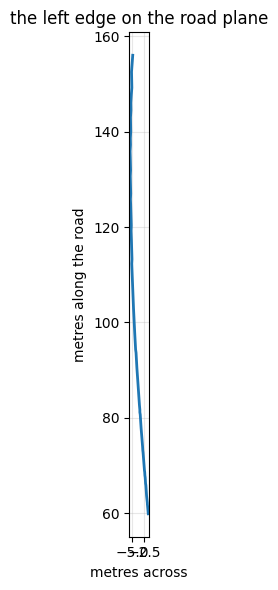

In [10]:
normal = np.array([a * fx, b * fy, c + a * PRINCIPAL_X + b * PRINCIPAL_Y])
normal = normal / np.linalg.norm(normal)

forward = np.array([0.0, 0.0, 1.0])                 # the optical axis...
forward = forward - (forward @ normal) * normal     # ...flattened into the plane
forward = forward / np.linalg.norm(forward)
forward = forward * np.sign(forward[2])
right = np.cross(forward, normal)
right = right * np.sign(right[0])

HOMOGRAPHY = np.vstack([right @ INVERSE_K, forward @ INVERSE_K, [a, b, c]])
PITCH_DEG = float(np.degrees(np.arcsin(abs(forward[1]))))   # camera, not road grade

edge = cv2.perspectiveTransform(LEFT[:, ::-1][:, None, :].astype(np.float32),
                                HOMOGRAPHY.astype(np.float32)).reshape(-1, 2)
SWEEP_M = float(edge[:, 0].max() - edge[:, 0].min())
LEFT_EDGE_POLY = np.polyfit(LEFT[:, 0], LEFT[:, 1], 2)
POLY_RMS = float((LEFT[:, 1] - np.polyval(LEFT_EDGE_POLY, LEFT[:, 0])).std())

# Use distance along the road plane to match the pipeline's vehicle zone.
NEAR_M, FAR_M = float(edge[:, 1].min()), float(edge[:, 1].max())

print(f'camera pitch {PITCH_DEG:.2f} deg   (bank is 0 by construction, not by measurement)')
print(f'left edge sweeps {SWEEP_M:.2f} m = {SWEEP_M / ROAD_WIDTH_M:.0%} of the road width; '
      f'quadratic residual {POLY_RMS:.2f} px rms')
print(f'visible road runs {NEAR_M:.0f} m to {FAR_M:.0f} m along the road plane')

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(edge[:, 0], edge[:, 1], linewidth=2)
ax.set_xlabel('metres across'); ax.set_ylabel('metres along the road')
ax.set_title('the left edge on the road plane')
ax.grid(alpha=.3); ax.set_aspect('equal'); plt.tight_layout(); plt.show()

## 6. Export calibration

Save the homography, scale estimates, curved boundary, and checks to `calibration.yaml`. Download the file into the app's `config/` folder.

**Interview takeaway:** Road width provides the metric reference; the lane traces and focal estimate determine the mapping. Explain the level-horizon assumption and scale checks alongside the result.


In [11]:
import yaml

yaml.SafeDumper.add_multi_representer(
    np.generic, lambda dumper, value: dumper.represent_data(value.item()))

body = {
    'homography': HOMOGRAPHY.tolist(),
    'camera_height_m': round(CAMERA_HEIGHT_M, 3),
    'horizon_row': round(HORIZON, 3),
    'focal_length_px': round(FOCAL_PX, 1),
    'focal_estimates': {name: round(value, 1) for name, value in FOCAL_ESTIMATES.items()},
    'scale_spread': round(SPREAD, 4),
    'left_edge_poly': [float(f'{value:.8g}') for value in LEFT_EDGE_POLY],
    'principal_point_x': round(float(PRINCIPAL_X), 3),
    'plane_coefficients': [float(f'{value:.10g}') for value in (a, b, c)],
    'grade_deg': round(PITCH_DEG, 3),
    'bank_deg': 0.0,
    'day_shift_px': DAY_SHIFT,
    'measured_width_m': round(ROAD_WIDTH_M, 3),
    'visible_road_m': [round(NEAR_M, 1), round(FAR_M, 1)],
    'source': 'notebooks/01_calibration.ipynb',
    'notes': (
        f'Horizon and camera height come from the painted road edges: two markings W '
        f'metres apart separate by W/h pixels per row and meet at the horizon, so one '
        f'line fit gives y0 = {HORIZON:.2f} (its zero crossing, rms {PAINT_RMS:.2f} px) '
        f'and h = {CAMERA_HEIGHT_M:.2f} m (W / its slope). Neither reads a focal length '
        f'or a depth map. measured_width_m is EXTERNAL -- {LANE_COUNT} lanes x '
        f'{LANE_WIDTH_M} m -- and is the only supplied number; it sets h and nothing '
        f'else, so it must not be quoted back as a check. UniDepth v2 supplies f alone; '
        f'focal_estimates records its intrinsics head against the f its own depth map '
        f'implies through this h and y0, and scale_spread is how far they sit apart. f '
        f'scales distance ALONG the road, and so speed, but not lateral position or '
        f'width. The plane is level by construction (a = 0): bank_deg is zero by '
        f'assumption and grade_deg is the CAMERA pitch, not road grade -- nothing here '
        f'sees gravity, and one vanishing point cannot pin the tilt of a horizon line. '
        f'The MUTCD dash cycle is NOT usable, the broken lane lines are not resolvable '
        f'at 320x240. Visible road {NEAR_M:.0f}-{FAR_M:.0f} m ALONG THE ROAD PLANE, the '
        f'same coordinate RoadFrame.in_zone gates on. The road curves: the left edge '
        f'sweeps {SWEEP_M:.2f} m, so lateral position must be measured from '
        f'left_edge_poly. Checks: the HOV lane reads {HOV_WIDTH_M:.2f} m with horizon '
        f'{HOV_HORIZON:.1f}; UniDepth f varies {FRAME_SPREAD:.1%} over {len(K_BY_SCENE)} '
        f'frames (median used).'
    ),
}

header = ('# GENERATED by notebooks/01_calibration.ipynb -- do not edit by hand.\n'
          '# What the footage cannot supply lives in config/site.yaml.\n')
target = (pathlib.Path('../config/calibration.yaml') if LOCAL.exists()
          else pathlib.Path('calibration.yaml'))
target.write_text(header + yaml.safe_dump(body, sort_keys=False, default_flow_style=False))
print(target.resolve(), '\n')
print(target.read_text())


/content/calibration.yaml 

# GENERATED by notebooks/01_calibration.ipynb -- do not edit by hand.
# What the footage cannot supply lives in config/site.yaml.
homography:
- - 0.0012602474912544563
  - 0.0
  - -0.21105547573458222
- - 0.0
  - -0.0001618723206819584
  - 1.0101300897396153
- - 0.0
  - 7.15146353348552e-05
  - -0.0006364419115237137
camera_height_m: 17.622
horizon_row: 8.899
focal_length_px: 793.5
focal_estimates:
  unidepth_intrinsics: 793.5
  unidepth_depth: 412.4
scale_spread: 0.4802
left_edge_poly:
- 0.0022174823
- -0.66968511
- 183.49876
principal_point_x: 167.471
plane_coefficients:
- 0.0
- 7.151463533e-05
- -0.0006364419115
grade_deg: 7.526
bank_deg: 0.0
day_shift_px:
  dx: -6.02
  dy: 5.35
measured_width_m: 18.15
visible_road_m:
- 59.8
- 156.0
source: notebooks/01_calibration.ipynb
notes: 'Horizon and camera height come from the painted road edges: two markings W
  metres apart separate by W/h pixels per row and meet at the horizon, so one line
  fit gives y0 = 8.90

In [12]:
if not LOCAL.exists():
    from google.colab import files
    files.download('calibration.yaml')      # save it into config/

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>